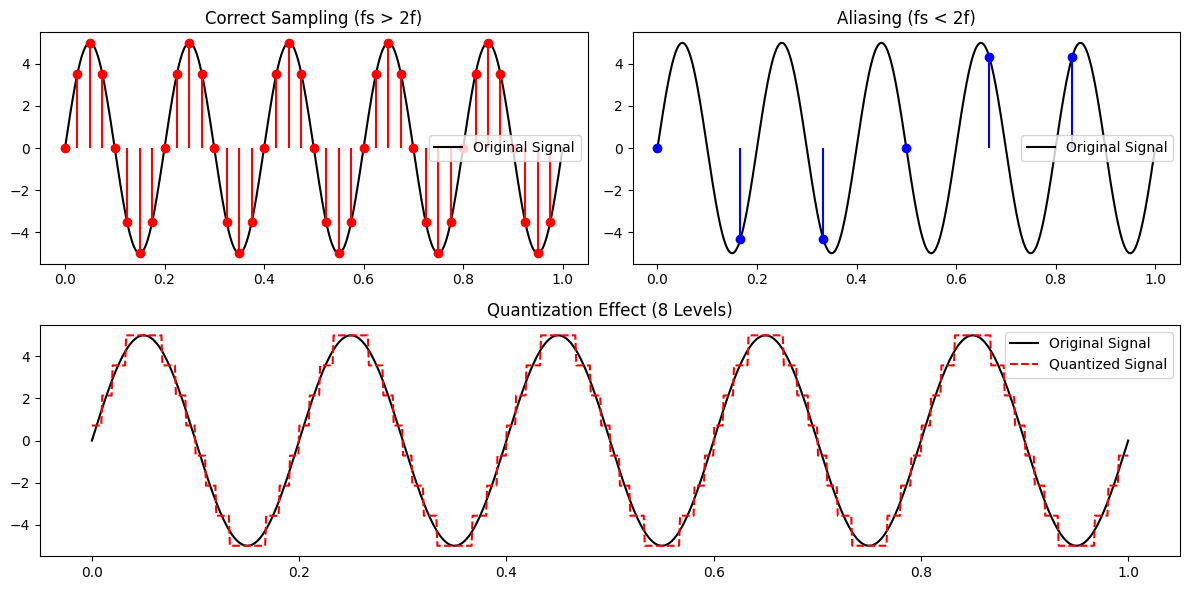

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Continuous-time signal
t = np.linspace(0, 1, 1000)  # High-resolution time
f = 5  # Base frequency (Hz)
y = 5 * np.sin(2 * np.pi * f * t)  # Original signal

# -------------------------------------------
# Aliasing: Sampling at different rates
# -------------------------------------------
fs1 = 40  # Correct Sampling (fs > 2f)
fs2 = 6   # Aliased Sampling (fs < 2f)

n1 = np.arange(0, 1, 1/fs1)  # Sample indices for fs1
n2 = np.arange(0, 1, 1/fs2)  # Sample indices for fs2

sampled1 = 5 * np.sin(2 * np.pi * f * n1)
sampled2 = 5 * np.sin(2 * np.pi * f * n2)

# -------------------------------------------
# Quantization: Reducing Amplitude Levels
# -------------------------------------------
num_levels = 8  # 8-bit quantization (3-bit resolution: 2^3 = 8 levels)
y_min, y_max = np.min(y), np.max(y)
quantized_y = np.round((y - y_min) / (y_max - y_min) * (num_levels - 1))  # Normalize & quantize
quantized_y = quantized_y / (num_levels - 1) * (y_max - y_min) + y_min  # Convert back

# -------------------------------------------
# Plot Results
# -------------------------------------------
plt.figure(figsize=(12, 6))

# Original vs Aliased Sampling
plt.subplot(2, 2, 1)
plt.plot(t, y, 'k', label="Original Signal")
plt.stem(n1, sampled1, linefmt='r-', markerfmt='ro', basefmt=" ")
plt.title("Correct Sampling (fs > 2f)")
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(t, y, 'k', label="Original Signal")
plt.stem(n2, sampled2, linefmt='b-', markerfmt='bo', basefmt=" ")
plt.title("Aliasing (fs < 2f)")
plt.legend()

# Original vs Quantized Signal
plt.subplot(2, 1, 2)
plt.plot(t, y, 'k', label="Original Signal")
plt.plot(t, quantized_y, 'r', label="Quantized Signal", linestyle='--')
plt.title("Quantization Effect (8 Levels)")
plt.legend()

plt.tight_layout()
plt.show()
